In [11]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [12]:
from dotenv import load_dotenv

load_dotenv()

True

In [13]:
## Data injestion using PDFs

from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

loader = PyPDFLoader("jose's_plan.pdf") # Path to the PDF file
text_splitter = RecursiveCharacterTextSplitter(chunk_size=2500, chunk_overlap=200)
docs = loader.load()
docs

[Document(metadata={'producer': 'LibreOffice 7.1', 'creator': 'Writer', 'creationdate': '2022-01-28T12:45:29+05:30', 'source': "jose's_plan.pdf", 'total_pages': 4, 'page': 0, 'page_label': '1'}, page_content='José\'s Plan\nAmalendu P\nTottenham Hotspur hasn\'t won a trophy in the last 13 years, since \nthey won the Carling cup in 2008 beating Chelsea at Wembley. \nFor Spurs Chairman Daniel Levy, the most logical move was to \nbring in a special manager. Someone who has plenty of experience\nwinning trophies and making history. \nJosé Mourinho was appointed Manager and Head Coach of \nTottenham Hotspur on 20th November 2019, following the \nsacking of ex-coach Mauricio Pochettinho. In his press conference\na week later, he was asked, "Do you think, not winning the final in\nThe Champions League pay a toll in the squad of Mauricio \nPochettinho ?". José replied, "I don\'t know, because I\'ve never lost\na champions league final." This shows José\'s mentality and that he\nwas under no pre

In [19]:
from langchain_chroma import Chroma
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

# Filter out complex metadata that ChromaDB can't handle
docs_split = text_splitter.split_documents(docs)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = Chroma.from_documents(
    documents=docs_split,
    embedding=embeddings,
    persist_directory="chroma_db",
)

retriever = vectorstore.as_retriever()

In [20]:
from langchain.tools.retriever import create_retriever_tool

# Fix the retriever tool creation - it should be a proper tool object, not a tuple
retriever_tool = create_retriever_tool(
    retriever,
    "Retrieval Tool",
    "Retrieve relevant details from the transcript based on a query about team members or activities"
)

In [21]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [22]:
from langchain_core.messages import HumanMessage, SystemMessage

def llm_response(state: State) -> dict:
  prompt = """Answer the following question based only the context provided.
      Think step by step and provide a detailed answer.
      Just give the final precise answer, no need to explain.
      <context>
      {context}
      </context>
      Question : {input}"""

  system_message = SystemMessage(content=prompt)
  llm_with_tools = llm.bind_tools([retriever_tool])
  response = llm_with_tools.invoke(state["messages"])
    
  return {"messages": [system_message] + state["messages"] + [response]}

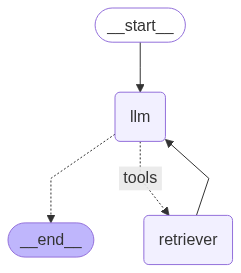

In [9]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(State)

workflow.add_node("llm", llm_response)
workflow.add_node("retriever", ToolNode([retriever_tool]))

workflow.add_edge(START, "llm")
workflow.add_conditional_edges(
    "llm",
    tools_condition,  # <- this is your branching function
    {
        "tools": "retriever",
        "__end__": END 
    }
)
workflow.add_edge("retriever", "llm")
workflow.add_edge("llm", END)


graph = workflow.compile(checkpointer=MemorySaver())

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
config = {"configurable":{"thread_id":"42"}}
response = graph.invoke({"messages": [HumanMessage(content="When did tottenham win their last trophy?")]}, config=config)

print("Response:", response["messages"][-1].content)

Response: 2008
